In [182]:
# Q1 Import Libraries

In [183]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt


In [184]:
# Q2 Load Dataset

In [185]:
test_df= pd.read_csv("/content/test_Y3wMUE5_7gLdaTN.csv")

In [186]:
test_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 367 entries, 0 to 366
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Loan_ID            367 non-null    object 
 1   Gender             356 non-null    object 
 2   Married            367 non-null    object 
 3   Dependents         357 non-null    object 
 4   Education          367 non-null    object 
 5   Self_Employed      344 non-null    object 
 6   ApplicantIncome    367 non-null    int64  
 7   CoapplicantIncome  367 non-null    int64  
 8   LoanAmount         362 non-null    float64
 9   Loan_Amount_Term   361 non-null    float64
 10  Credit_History     338 non-null    float64
 11  Property_Area      367 non-null    object 
dtypes: float64(3), int64(2), object(7)
memory usage: 34.5+ KB


In [187]:
# Q3 Check Missing Values

In [188]:
test_df.isnull().sum()

,0
Loan_ID,0
Gender,11
Married,0
Dependents,10
Education,0
Self_Employed,23
ApplicantIncome,0
CoapplicantIncome,0
LoanAmount,5
Loan_Amount_Term,6


Both Dataset Were loaded to understand datatype, missing values.

In [189]:
#Q4 Handle Missing Values in  Loan Amount (Median)

In [190]:
loan_median= test_df.groupby("Property_Area")["LoanAmount"].median()


In [191]:
loan_median

,LoanAmount
Property_Area,
Rural,130.5
Semiurban,123.0
Urban,125.0


In [192]:
# Fill missing values using group median

test_df["LoanAmount"] = test_df["LoanAmount"].fillna(test_df.groupby("Property_Area")["LoanAmount"].transform('median'))

In [193]:
test_df["LoanAmount"]

,LoanAmount
0,110.0
1,126.0
2,208.0
3,100.0
4,78.0
...,...
362,113.0
363,115.0
364,126.0
365,158.0


In [194]:
# Why Median? Median is robust to outliers

In [195]:
# Q5 Outliers in Incomes (IQR Method)

In [196]:
Q1 = test_df['ApplicantIncome'].quantile(0.25)
Q3 = test_df['ApplicantIncome'].quantile(0.75)
IQR= Q3 - Q1

Lower_Bound = Q1-1.5 * IQR
Upper_Bound = Q3+1.5 * IQR

In [197]:
Lower_Bound

np.float64(-430.0)

In [198]:
Upper_Bound

np.float64(8354.0)

In [199]:
# Q6. Remove Outliers from Test Data (Using  IQR)

In [200]:
test_df = test_df[
    (test_df["ApplicantIncome"] >= Lower_Bound) &
    (test_df["ApplicantIncome"] <= Upper_Bound)]

In [201]:
test_df

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area
0,LP001015,Male,Yes,0,Graduate,No,5720,0,110.0,360.0,1.0,Urban
1,LP001022,Male,Yes,1,Graduate,No,3076,1500,126.0,360.0,1.0,Urban
2,LP001031,Male,Yes,2,Graduate,No,5000,1800,208.0,360.0,1.0,Urban
3,LP001035,Male,Yes,2,Graduate,No,2340,2546,100.0,360.0,NaN,Urban
4,LP001051,Male,No,0,Not Graduate,No,3276,0,78.0,360.0,1.0,Urban
...,...,...,...,...,...,...,...,...,...,...,...,...
361,LP002969,Male,Yes,1,Graduate,No,2269,2167,99.0,360.0,1.0,Semiurban
362,LP002971,Male,Yes,3+,Not Graduate,Yes,4009,1777,113.0,360.0,1.0,Urban
363,LP002975,Male,Yes,0,Graduate,No,4158,709,115.0,360.0,1.0,Urban
364,LP002980,Male,No,0,Graduate,No,3250,1993,126.0,360.0,NaN,Semiurban


In [202]:
# Q7 Average Loan Amount by Gender and  Property Areafor Credit History = 1.0

In [203]:
avg_loan = (
    test_df[test_df['Credit_History'] == 1.0]
    .groupby(['Gender', 'Property_Area'])['LoanAmount']
    .mean()
    .reset_index())


In [204]:
avg_loan

,Gender,Property_Area,LoanAmount
0,Female,Rural,131.833333
1,Female,Semiurban,116.200000
2,Female,Urban,108.500000
3,Male,Rural,133.017241
4,Male,Semiurban,126.254545
5,Male,Urban,130.880952


# Insight:
Applicants with valid credit history tend to qualifyfor higher loan amounts.

In [205]:
# Q8 Boxplot of  Applicant Income by Education


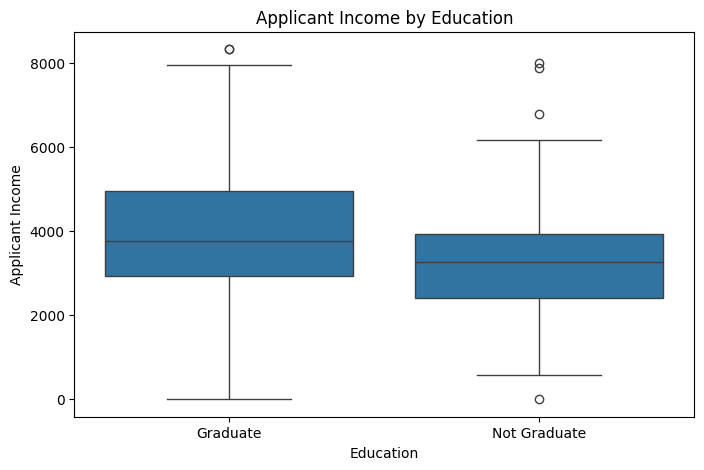

In [206]:


plt.figure(figsize=(8,5))
sns.boxplot(x='Education', y='ApplicantIncome', data=test_df)
plt.title('Applicant Income by Education')
plt.xlabel('Education')
plt.ylabel('Applicant Income')
plt.show()


#Insights
Graduates typically earn a higher median income than non-graduates, showing that education influences earning potential.

In [207]:
# Q9 Correlation Heatmap for numeric feature

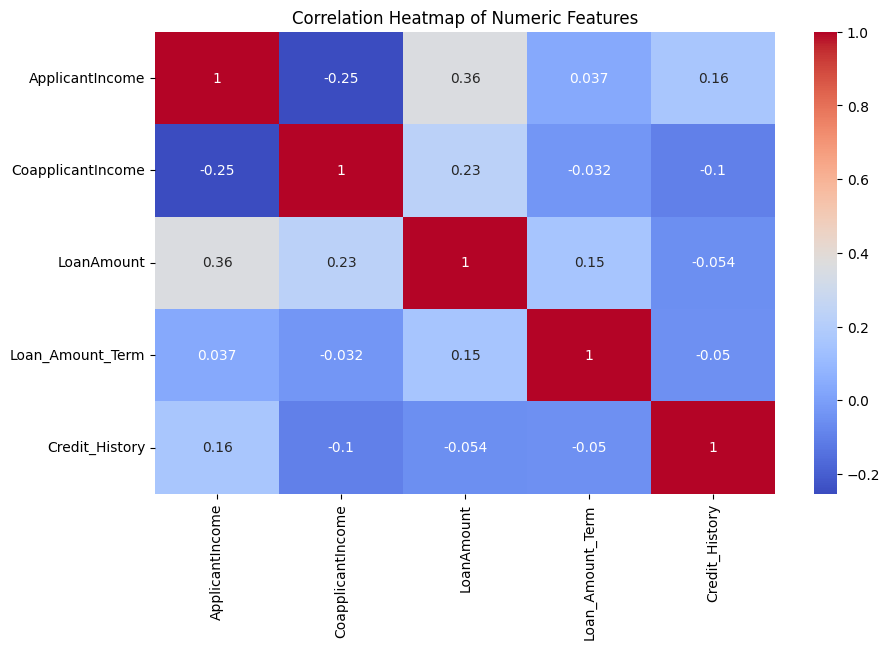

In [208]:
plt.figure(figsize=(10,6))
sns.heatmap(test_df.select_dtypes(include="number").corr(),
    annot=True,
    cmap="coolwarm")
plt.title("Correlation Heatmap of Numeric Features")
plt.show()



#Insights
 - LoanAmount shows a positive correlation with ApplicantIncome, indicating  higher-income applicants tend to request larger loan amounts.
- DTI is positively correlated with LoanAmount and negatively correlated with ApplicantIncome, confirming that higher loans relative to income increase repayment burden.
- Credit history doesn’t strongly relate to income or loan amount, meaning it’s judged mostly on its own.

Calculate Debt to income ratio(DTI)

In [209]:
test_df["DTI"] = test_df["LoanAmount"] / test_df["ApplicantIncome"]


In [210]:
test_df["DTI"]

,DTI
0,0.019231
1,0.040962
2,0.041600
3,0.042735
4,0.023810
...,...
361,0.043632
362,0.028187
363,0.027658
364,0.038769


In [211]:
income_median = test_df["ApplicantIncome"].median()

In [212]:
income_median

3620.0

In [213]:
# Q11 Identify High-Risk Segments

In [214]:


high_risk = test_df[
    (test_df["Property_Area"] == "Rural") &
    (test_df["ApplicantIncome"] < income_median) &
    (test_df["DTI"] > 0.40)]





In [215]:

high_risk

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,DTI
25,LP001153,Male,No,0,Graduate,No,0,24000,148.0,360.0,0.0,Rural,inf


#Insights
- Applicants from rural areas with lower income levels and higher
debt-to-income ratios represent a higher credit risk. A DTI above 40%
- indicates increased repayment burden, particularly for applicants with
limited income capacity.


#Conclusion
- The analysis shows that credit history is the main factor for loan approval.
- People with low income and high loan amounts are more risky. Cleaning the data helped make the results more accurate.